# Model Training Phase


---
## 1. **Import Libraries**

In [1]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms, models

print(f'PyTorch version : {torch.__version__}')
print(f'Torchvision ver : {torchvision.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {device}')

PyTorch version : 2.10.0+cpu
Torchvision ver : 0.25.0+cpu
Using device    : cpu


---
## 2. **Load Pretrained MobileNetV2** (Transfer Learning)

In [2]:
model = models.mobilenet_v2(pretrained=True)
print('✅ MobileNetV2 loaded with ImageNet pretrained weights')
print(f'Original classifier: {model.classifier}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 144MB/s]

✅ MobileNetV2 loaded with ImageNet pretrained weights
Original classifier: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


---
## 3. **Freeze Backbone Layers**

In [3]:
# Freeze all feature extraction layers
for param in model.features.parameters():
    param.requires_grad = False

frozen = sum(1 for p in model.features.parameters() if not p.requires_grad)
print(f'✅ Frozen {frozen} parameter tensors in backbone')
print('Only the classifier head will be trained.')

✅ Frozen 156 parameter tensors in backbone
Only the classifier head will be trained.


---
##4. **Modify Classifier Layer**

In [4]:
NUM_CLASSES = 2

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'✅ Classifier replaced → output size = {NUM_CLASSES} classes')
print(f'   Trainable params : {trainable:,}')
print(f'   Total params     : {total:,}')
print(model.classifier)

✅ Classifier replaced → output size = 2 classes
   Trainable params : 328,450
   Total params     : 2,552,322
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=2, bias=True)
)


---
##5. **Prepare Dataset Loaders**

In [7]:
from google.colab import drive
drive.mount('/content/drive')
import os
BASE_DIR = '/content/drive/MyDrive/data/Dataset_Resized'
for split in ['Train', 'Validation', 'Test']:
    path = os.path.join(BASE_DIR, split)
    count = sum(len(files) for _, _, files in os.walk(path))
    print(f'{split}: {count} images found')

IMG_SIZE   = 224
BATCH_SIZE = 32

#ImageNet normalisation stats (required for MobileNetV2)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
#Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

#Datasets
train_dataset = datasets.ImageFolder(os.path.join(BASE_DIR, 'Train'),      transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(BASE_DIR, 'Validation'), transform=val_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(BASE_DIR, 'Test'),       transform=val_transforms)

#DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print(f'Classes      : {class_names}')
print(f'Train images : {len(train_dataset)}')
print(f'Val   images : {len(val_dataset)}')
print(f'Test  images : {len(test_dataset)}')
print(f'Batch size   : {BATCH_SIZE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 10205 images found
Validation: 800 images found
Test: 992 images found
Classes      : ['WithMask', 'WithoutMask']
Train images : 10205
Val   images : 800
Test  images : 992
Batch size   : 32


---
##6. **Define Loss Function & Optimizer**

In [8]:
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print('✅ Loss      : CrossEntropyLoss')
print('✅ Optimizer : Adam  (lr=0.001, weight_decay=1e-4)')
print('✅ Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)')

✅ Loss      : CrossEntropyLoss
✅ Optimizer : Adam  (lr=0.001, weight_decay=1e-4)
✅ Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)


---
##7. **Training Loop**

1- Containers

In [9]:
import copy
NUM_EPOCHS = 15
#History containers
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

#for the early stopping state
PATIENCE= 4
best_val_loss=float('inf')
best_model_wts=copy.deepcopy(model.state_dict())
epochs_no_improve = 0

2- **Training Loop**

Early stopping feature is integrated inside the training loop

 - Early stopping monitors **validation loss** and halts training when no improvement is seen for `PATIENCE=4` consecutive epochs. This:
1.   Prevents overfitting
2.   Saves compute time
3.   Ensures the best model checkpoint is always retained

In [10]:

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ---------- TRAIN ----------
    model.train()
    running_loss, running_correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # Forward pass
        loss    = criterion(outputs, labels)
        loss.backward()                  # Backpropagation
        optimizer.step()                 # Weight update

        running_loss    += loss.item() * images.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = running_loss    / len(train_dataset)
    train_acc  = running_correct / len(train_dataset)

    # ---------- VALIDATE ----------
    model.eval()
    val_running_loss, val_running_correct = 0.0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_running_loss    += loss.item() * images.size(0)
            val_running_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss = val_running_loss    / len(val_dataset)
    val_acc  = val_running_correct / len(val_dataset)

    # ---------- SCHEDULER ----------
    scheduler.step(val_loss)

    # ---------- LOG ----------
    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_acc' ].append(train_acc)
    history['val_acc'   ].append(val_acc)

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  '
          f'({elapsed:.1f}s)')

    # ---------- EARLY STOPPING (Step 8) ----------
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f'  → ✅ Val loss improved to {best_val_loss:.4f}. Model saved.')
    else:
        epochs_no_improve += 1
        print(f'  → ⚠️  No improvement ({epochs_no_improve}/{PATIENCE})')
        if epochs_no_improve >= PATIENCE:
            print(f'  → 🛑 Early stopping triggered at epoch {epoch}.')
            break

print('\n✅ Training complete!')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [01/15]  Train Loss: 0.1125  Train Acc: 0.9552  |  Val Loss: 0.0188  Val Acc: 0.9975  (1642.9s)
  → ✅ Val loss improved to 0.0188. Model saved.
Epoch [02/15]  Train Loss: 0.0731  Train Acc: 0.9732  |  Val Loss: 0.0196  Val Acc: 0.9938  (677.4s)
  → ⚠️  No improvement (1/4)
Epoch [03/15]  Train Loss: 0.0711  Train Acc: 0.9728  |  Val Loss: 0.0314  Val Acc: 0.9888  (698.3s)
  → ⚠️  No improvement (2/4)
Epoch [04/15]  Train Loss: 0.0648  Train Acc: 0.9761  |  Val Loss: 0.0219  Val Acc: 0.9912  (707.1s)
  → ⚠️  No improvement (3/4)
Epoch [05/15]  Train Loss: 0.0518  Train Acc: 0.9800  |  Val Loss: 0.0132  Val Acc: 0.9950  (691.7s)
  → ✅ Val loss improved to 0.0132. Model saved.
Epoch [06/15]  Train Loss: 0.0443  Train Acc: 0.9829  |  Val Loss: 0.0193  Val Acc: 0.9912  (693.2s)
  → ⚠️  No improvement (1/4)
Epoch [07/15]  Train Loss: 0.0446  Train Acc: 0.9820  |  Val Loss: 0.0155  Val Acc: 0.9950  (701.8s)
  → ⚠️  No improvement (2/4)
Epoch [08/15]  Train Loss: 0.0386  Train Acc: 0.985

---
## 9. **Save the Best Model**

In [11]:
MODEL_PATH = 'mask_detector.pth'
model.load_state_dict(best_model_wts)
torch.save({
    'model_state_dict' : model.state_dict(),
    'class_names'      : class_names,
    'img_size'         : IMG_SIZE,
    'mean'             : MEAN,
    'std'              : STD,
    'best_val_loss'    : best_val_loss,
}, MODEL_PATH)

print(f'Best model saved → {MODEL_PATH}')
print(f'Best validation loss : {best_val_loss:.4f}')

Best model saved → mask_detector.pth
Best validation loss : 0.0073


---
##10. **Plot Training Curves**

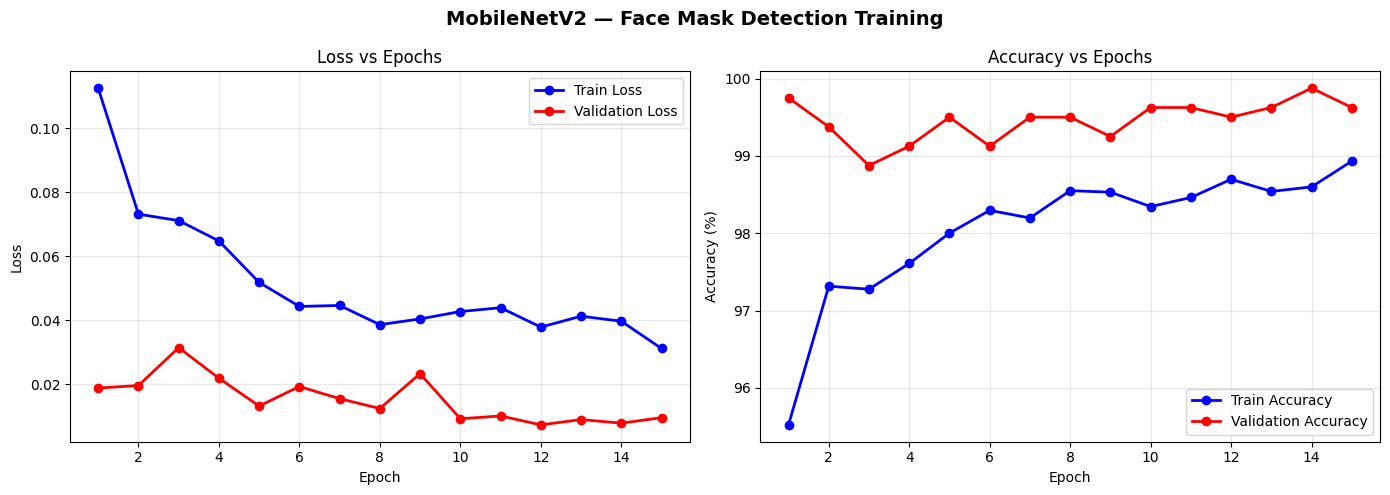

Saved → training_curves.png


In [12]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Face Mask Detection Training', fontsize=14, fontweight='bold')

#Loss Curve
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss',      linewidth=2)
ax.plot(epochs_ran, history['val_loss'],   'r-o', label='Validation Loss', linewidth=2)
ax.set_title('Loss vs Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
#Accuracy Curve
ax = axes[1]
ax.plot(epochs_ran, [a * 100 for a in history['train_acc']], 'b-o', label='Train Accuracy',      linewidth=2)
ax.plot(epochs_ran, [a * 100 for a in history['val_acc']],   'r-o', label='Validation Accuracy', linewidth=2)
ax.set_title('Accuracy vs Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

---
## 11. **Evaluate on Test Set**

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test Accuracy: 99.60%


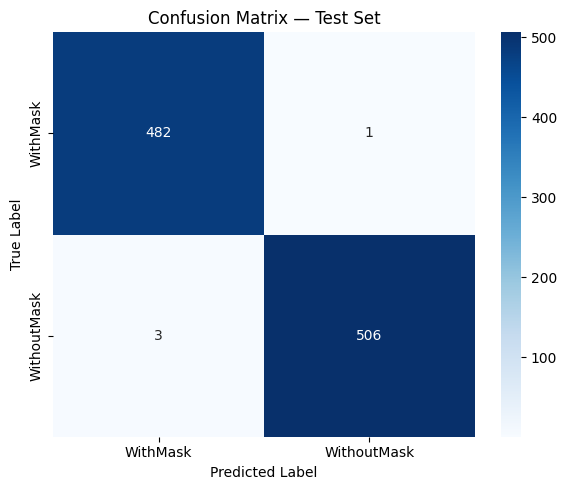


Classification Report:
              precision    recall  f1-score   support

    WithMask       0.99      1.00      1.00       483
 WithoutMask       1.00      0.99      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992



In [13]:
model.eval()
test_correct = 0

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds   = outputs.argmax(1)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / len(test_dataset)
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names))

---

## **Model Configuration Used**

| Setting | Value |
|---------|-------|
| Backbone | MobileNetV2 (ImageNet pretrained) |
| Image Size | 224 × 224 |
| Batch Size | 32 |
| Max Epochs | 15 |
| Optimizer | Adam (lr=0.001) |
| Loss | CrossEntropyLoss |
| Scheduler | ReduceLROnPlateau |
| Early Stop Patience | 4 epochs |